Imports

In [32]:
import pandas as pd
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns

Load sql features

In [33]:
conn = sqlite3.connect("../data/database.db")
df = pd.read_sql_query(
    "SELECT * FROM customer_features_labeled",
    conn
)
df.head()

,customer_id,age,gender,location,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed,spend_quartile,session_quartile,churn_label
0,111,55,Male,EU,3,42.103333,126.31,23.906667,13.000000,1,4,0
1,459,21,Female,US,3,47.570000,142.71,9.725000,9.500000,1,1,1
2,149,25,Male,EU,3,76.016667,228.05,17.270000,3.000000,1,3,0
3,40,52,Female,US,3,80.376667,241.13,16.900000,7.666667,1,3,0
4,384,47,Female,US,3,96.096667,288.29,17.700000,9.000000,1,3,0


Prepare Feature Table
1. Select Features

In [34]:
features = [
    "age",
    "transaction_count",
    "avg_transaction_amount",
    "total_spend",
    "avg_session_duration",
    "avg_pages_viewed"
]

X = df[features]
y = df["churn_label"]

2.Train-Test-Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scaale Features
1.Standardization

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Model
1.Logistic reg(Baseline)

In [37]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

2. Multi-Layered Perceptron(core)

In [42]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=600,
    random_state=42,
    # class_weight="balanced"
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

Evalute Model
1.Accuracy

In [43]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))

Logistic Regression Accuracy: 0.94
MLP Accuracy: 0.97


2.Confusion Matrix

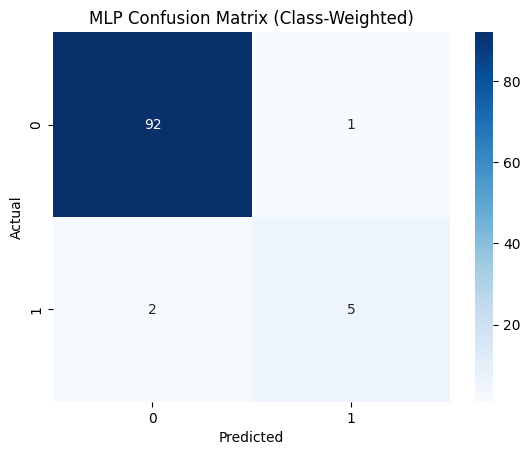

In [44]:
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("MLP Confusion Matrix (Class-Weighted)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [45]:
print("Train accuracy:", mlp.score(X_train_scaled, y_train))
print("Test accuracy:", mlp.score(X_test_scaled, y_test))

Train accuracy: 1.0
Test accuracy: 0.97


Classification Report

In [46]:
print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        93
           1       0.83      0.71      0.77         7

    accuracy                           0.97       100
   macro avg       0.91      0.85      0.88       100
weighted avg       0.97      0.97      0.97       100



ROC-AUC

In [47]:
y_proba = mlp.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9969278033794163


Overfitting check

In [48]:
print("Train accuracy:", mlp.score(X_train_scaled, y_train))
print("Test accuracy:", mlp.score(X_test_scaled, y_test))

Train accuracy: 1.0
Test accuracy: 0.97
